In [ ]:
## %pip install qiskit-aer qiskit-algorithms qiskit-ibm-runtime qiskit-nature pyscf networkx

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import qiskit
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import StatevectorEstimator

# Qiskit Nature (electronic structure -> qubit Hamiltonian)
import qiskit_nature
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.mappers import ParityMapper
from qiskit_nature.second_q.transformers import ActiveSpaceTransformer
from qiskit_nature.second_q.circuit.library import HartreeFock, UCCSD

# PySCF (classical electronic structure backend)
import pyscf


In [2]:
## build the LiH electronic structure problem at equilibrium

# Equilibrium bond length (commonly used 
bond_length = 1.5474  # Angstrom

driver = PySCFDriver(
    atom=f"Li 0.0 0.0 0.0; H 0.0 0.0 {bond_length}",
    basis="sto3g",
    charge=0,
    spin=0,
    unit=DistanceUnit.ANGSTROM,
)

problem = driver.run()

print(f"Number of spatial orbitals : {problem.num_spatial_orbitals}")
print(f"Number of spin orbitals    : {2 * problem.num_spatial_orbitals}")
print(f"Number of particles        : {problem.num_particles}")
print(f"Nuclear repulsion energy   : {problem.nuclear_repulsion_energy:.6f} Hartree")
print(f"Reference HF energy        : {problem.reference_energy:.6f} Hartree")

Number of spatial orbitals : 6
Number of spin orbitals    : 12
Number of particles        : (2, 2)
Nuclear repulsion energy   : 1.025935 Hartree
Reference HF energy        : -7.863114 Hartree


In [3]:
"""
To reproduce Kandala et al. (Nature 549, 242-246, 2017): (not 100%)
- Active orbitals: H 1s (MO1), Li 2s (MO2), Li 2px (MO3) → 3 spatial orbitals
- Active electrons: 4 (including frozen Li 1s contribution) → particles = (2,2)
- Frozen core energy shift (-7.818690 Hartree) is extracted from
  ActiveSpaceTransformer(2e, 3 orbitals) and manually added back,
  since ActiveSpaceTransformer(4e, 3 orbitals) does not compute it.
- Result: 4 qubits, 100 Pauli terms (paper: 99, difference may be IIII constant term handling)
"""

# using (2e, 3 orbitals) get correct energy shift
problem_ref = driver.run()
ref_transformer = ActiveSpaceTransformer(num_electrons=2, num_spatial_orbitals=3)
problem_ref = ref_transformer.transform(problem_ref)
frozen_core_shift = problem_ref.hamiltonian.constants["ActiveSpaceTransformer"]

# then using (4e, 3 orbitals) to construct Hamiltonian
problem = driver.run()
active_transformer = ActiveSpaceTransformer(num_electrons=4, num_spatial_orbitals=3)
problem = active_transformer.transform(problem)
problem.hamiltonian.constants["frozen_core"] = frozen_core_shift

print(f"Hamiltonian constants : {problem.hamiltonian.constants}")

Hamiltonian constants : {'nuclear_repulsion_energy': np.float64(1.0259348796432726), 'ActiveSpaceTransformer': np.float64(0.0), 'frozen_core': np.float64(-7.818690295586686)}


In [4]:
## map fermionic Hamiltonian to qubit Hamiltonian
mapper = ParityMapper(num_particles=problem.num_particles)
qubit_hamiltonian = mapper.map(problem.hamiltonian.second_q_op())

print(f"Number of qubits      : {qubit_hamiltonian.num_qubits}")
print(f"Number of Pauli terms : {len(qubit_hamiltonian)}")

print(f"\nFirst 5 Pauli terms:")
for i, (pauli, coeff) in enumerate(qubit_hamiltonian.to_list()):
    if i >= 5: break
    print(f"  {pauli} : {coeff.real:+.6f}")

# FCI reference -> diagonalize the 4-qubit Hamiltonian directly
H_matrix = qubit_hamiltonian.to_matrix()
fci_electronic = float(np.linalg.eigvalsh(H_matrix)[0])
print(f"\nFCI electronic energy : {fci_electronic:.6f} Hartree")

fci_total = fci_electronic + problem.nuclear_repulsion_energy
print(f"FCI total energy      : {fci_total:.6f} Hartree")
print(f"Expected (paper)      : ~-7.78 Hartree @ R = 1.5474 Å")

Number of qubits      : 4
Number of Pauli terms : 100

First 5 Pauli terms:
  IIII : -5.788771
  IIIZ : +1.632178
  IIZX : -0.018262
  IIIX : +0.018262
  IIXX : -0.039128

FCI electronic energy : -8.889374 Hartree
FCI total energy      : -7.863439 Hartree
Expected (paper)      : ~-7.78 Hartree @ R = 1.5474 Å


In [5]:
# # UCCSD ansatz with Hartree-Fock initial state

# # Hartree-Fock state --> the classical mean-field reference
# hf_state = HartreeFock(
#     num_spatial_orbitals=problem.num_spatial_orbitals,
#     num_particles=problem.num_particles,
#     qubit_mapper=mapper,
# )

# # UCCSD ansatz 
# ansatz = UCCSD(
#     num_spatial_orbitals=problem.num_spatial_orbitals,
#     num_particles=problem.num_particles,
#     qubit_mapper=mapper,
#     initial_state=hf_state,
# )

# print(f"Number of qubits      : {ansatz.num_qubits}")
# print(f"Number of parameters  : {ansatz.num_parameters}")
# print(f"Circuit depth         : {ansatz.decompose().depth()}")

In [6]:
## HEA ansatz tailored to cross 5q topology (center = q2)
# entanglement follows physical connectivity: q0-q2, q1-q2, q3-q2
from qiskit.circuit.library import efficient_su2


ansatz = efficient_su2(
    num_qubits=4,
    reps=1,
    entanglement=[[0,2],[1,2],[3,2]],
    su2_gates=["rz", "ry"]          # change here for native single qubit gate  (in paper ZXZ)
)   

print(f"Number of qubits     : {ansatz.num_qubits}")
print(f"Number of parameters : {ansatz.num_parameters}")  
print(f"Circuit depth        : {ansatz.decompose().depth()}")

Number of qubits     : 4
Number of parameters : 16
Circuit depth        : 7


Initial energy (theta=0) : -7.095890 Hartree

Running VQE (HEA + L-BFGS-B, noiseless)...

VQE electronic energy : -8.889049 Hartree
FCI electronic energy : -8.889374 Hartree
Error                 : +0.3254 mHartree
Chemical accuracy     : YES (threshold 1.6 mHa)
Function evaluations  : 663


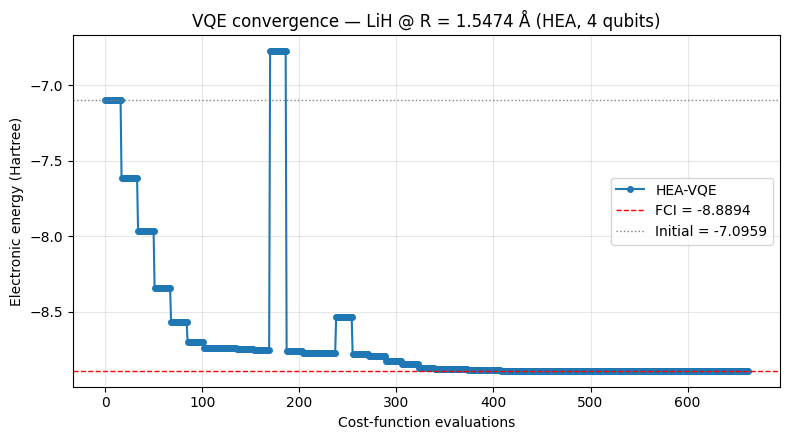

In [7]:
## Noiseless VQE benchmark using HEA ansatz with **L-BFGS-B** optimizer to verify ansatz expressibility against FCI
estimator = StatevectorEstimator()

history = {"iter": 0, "energies": []}

def cost_function(params):
    """Compute <psi(params) | H | psi(params)>"""
    job = estimator.run([(ansatz, qubit_hamiltonian, [params])])
    energy = float(np.asarray(job.result()[0].data.evs).reshape(-1)[0])
    history["iter"] += 1
    history["energies"].append(energy)
    return energy

# energy at theta = 0 (HEA initial state, not necessarily HF)
# x0 = np.zeros(ansatz.num_parameters)
# initial_energy = cost_function(x0)

rng = np.random.default_rng(42)
x0 = rng.uniform(-np.pi, np.pi, ansatz.num_parameters)
initial_energy = cost_function(x0)
print(f"Initial energy (theta=0) : {initial_energy:.6f} Hartree")

history = {"iter": 0, "energies": []}

print("\nRunning VQE (HEA + L-BFGS-B, noiseless)...")
result = minimize(
    cost_function,
    x0=x0,
    method="L-BFGS-B",
    options={"maxiter": 200, "ftol": 1e-12, "gtol": 1e-8},
)

vqe_energy_electronic = float(result.fun)
n_evals = history["iter"]

error_mHa = (vqe_energy_electronic - fci_electronic) * 1000
print(f"\nVQE electronic energy : {vqe_energy_electronic:.6f} Hartree")
print(f"FCI electronic energy : {fci_electronic:.6f} Hartree")
print(f"Error                 : {error_mHa:+.4f} mHartree")
print(f"Chemical accuracy     : {'YES' if abs(error_mHa) < 1.6 else 'NO'} (threshold 1.6 mHa)")
print(f"Function evaluations  : {n_evals}")

plt.figure(figsize=(8, 4.5))
plt.plot(history["energies"], lw=1.5, marker="o", ms=4, label="HEA-VQE")
plt.axhline(fci_electronic, color="r", ls="--", lw=1, label=f"FCI = {fci_electronic:.4f}")
plt.axhline(initial_energy, color="gray", ls=":", lw=1, label=f"Initial = {initial_energy:.4f}")
plt.xlabel("Cost-function evaluations")
plt.ylabel("Electronic energy (Hartree)")
plt.title(f"VQE convergence — LiH @ R = {bond_length} Å (HEA, 4 qubits)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Initial energy (theta=0) : -7.095890 Hartree

Running VQE (HEA + SPSA, noiseless)...

VQE electronic energy : -8.742378 Hartree
FCI electronic energy : -8.889374 Hartree
Error                 : +146.9965 mHartree
Chemical accuracy     : NO (threshold 1.6 mHa)
Function evaluations  : 551


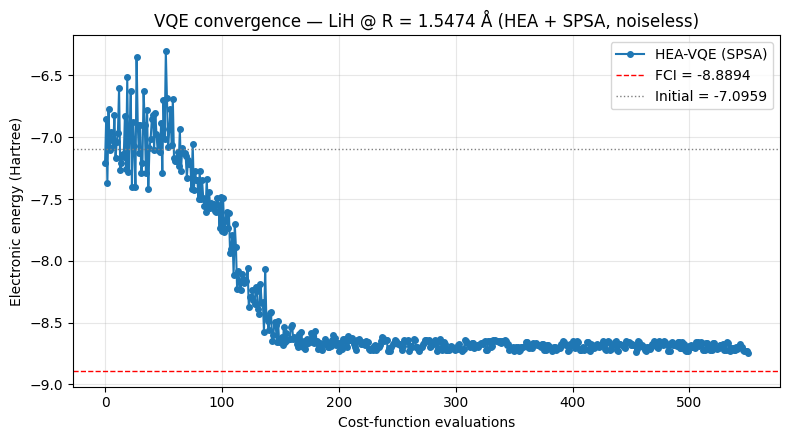

In [8]:
## Noiseless VQE benchmark using HEA ansatz with SPSA optimizer to validate optimizer behavior in noise-free conditions
from qiskit_algorithms.optimizers import SPSA 

"""
Noiseless should use L-BFGS-B
SPSA is for noisy env (since it only need 2 energy measurement)
So here, outcome is not good at all
"""

spsa = SPSA(
    maxiter=250,           
    blocking=False,        
    allowed_increase=0.1,  
    trust_region=False,    
    learning_rate=None,    
    perturbation=None,
    last_avg=25,            
    resamplings=1,        
    perturbation_dims=None, 
)

estimator = StatevectorEstimator()

history = {"iter": 0, "energies": []}

def cost_function(params):
    """Compute <psi(params) | H | psi(params)>"""
    job = estimator.run([(ansatz, qubit_hamiltonian, [params])])
    energy = float(np.asarray(job.result()[0].data.evs).reshape(-1)[0])
    history["iter"] += 1
    history["energies"].append(energy)
    return energy


print(f"Initial energy (theta=0) : {initial_energy:.6f} Hartree")

history = {"iter": 0, "energies": []}

print("\nRunning VQE (HEA + SPSA, noiseless)...")


result = spsa.minimize(cost_function, x0=x0)

vqe_energy_electronic = float(result.fun)
n_evals = history["iter"]

error_mHa = (vqe_energy_electronic - fci_electronic) * 1000
print(f"\nVQE electronic energy : {vqe_energy_electronic:.6f} Hartree")
print(f"FCI electronic energy : {fci_electronic:.6f} Hartree")
print(f"Error                 : {error_mHa:+.4f} mHartree")
print(f"Chemical accuracy     : {'YES' if abs(error_mHa) < 1.6 else 'NO'} (threshold 1.6 mHa)")
print(f"Function evaluations  : {n_evals}")

plt.figure(figsize=(8, 4.5))
plt.plot(history["energies"], lw=1.5, marker="o", ms=4, label="HEA-VQE (SPSA)")
plt.axhline(fci_electronic, color="r", ls="--", lw=1, label=f"FCI = {fci_electronic:.4f}")
plt.axhline(initial_energy, color="gray", ls=":", lw=1, label=f"Initial = {initial_energy:.4f}")
plt.xlabel("Cost-function evaluations")
plt.ylabel("Electronic energy (Hartree)")
plt.title(f"VQE convergence — LiH @ R = {bond_length} Å (HEA + SPSA, noiseless)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

R=0.50  L-BFGS-B=-7.0284  SPSA=-6.8906  FCI=-7.0291
R=0.60  L-BFGS-B=-7.2998  SPSA=-7.2782  FCI=-7.2998
R=0.70  L-BFGS-B=-7.4860  SPSA=-7.4689  FCI=-7.4862
R=0.80  L-BFGS-B=-7.6158  SPSA=-7.5152  FCI=-7.6160
R=0.90  L-BFGS-B=-7.7059  SPSA=-7.6821  FCI=-7.7059
R=1.00  L-BFGS-B=-7.7674  SPSA=-7.5700  FCI=-7.7676
R=1.10  L-BFGS-B=-7.8088  SPSA=-7.6476  FCI=-7.8090
R=1.20  L-BFGS-B=-7.8357  SPSA=-7.8015  FCI=-7.8358
R=1.30  L-BFGS-B=-7.8520  SPSA=-7.4979  FCI=-7.8522
R=1.40  L-BFGS-B=-7.8606  SPSA=-7.7629  FCI=-7.8608
R=1.45  L-BFGS-B=-7.8628  SPSA=-7.8322  FCI=-7.8629
R=1.50  L-BFGS-B=-7.8636  SPSA=-7.8007  FCI=-7.8637
R=1.55  L-BFGS-B=-7.8633  SPSA=-7.8147  FCI=-7.8634
R=1.60  L-BFGS-B=-7.8620  SPSA=-7.8365  FCI=-7.8622
R=1.65  L-BFGS-B=-7.8601  SPSA=-7.7832  FCI=-7.8602
R=1.70  L-BFGS-B=-7.8575  SPSA=-7.8505  FCI=-7.8576
R=1.75  L-BFGS-B=-7.8539  SPSA=-7.7183  FCI=-7.8543
R=1.80  L-BFGS-B=-7.8500  SPSA=-7.8240  FCI=-7.8505
R=2.00  L-BFGS-B=-7.8315  SPSA=-7.7864  FCI=-7.8316
R=2.20  L-BF

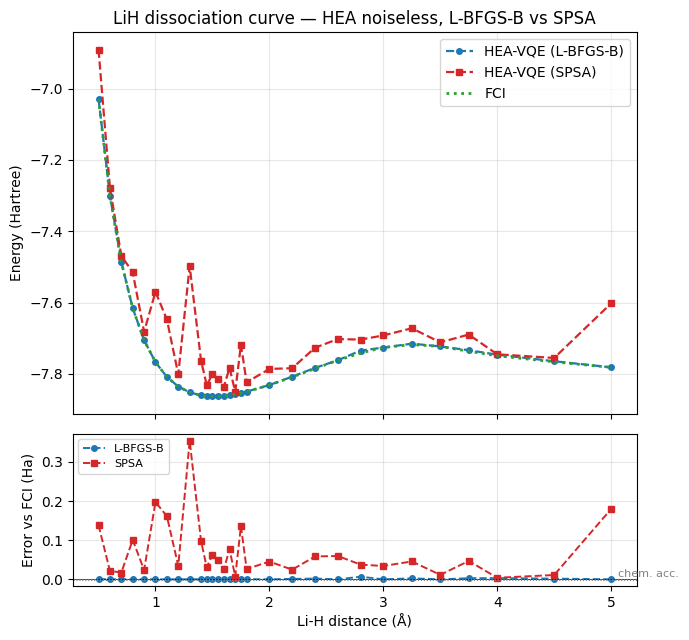

In [9]:
## scan bond length and plot PEC (HEA, noiseless using L-BFGS-B and SPSA)

def run_vqe_at_distance(R, optimizer="lbfgsb"):
    """
    Full HEA-VQE pipeline at one Li-H distance.
    optimizer: "lbfgsb" or "spsa"
    Returns: (initial_total, VQE_total, FCI_total) in Hartree.
    """
    drv = PySCFDriver(
        atom=f"Li 0.0 0.0 0.0; H 0.0 0.0 {R}",
        basis="sto3g", charge=0, spin=0, unit=DistanceUnit.ANGSTROM,
    )

    prob_ref = drv.run()
    frozen_shift = ActiveSpaceTransformer(2, 3).transform(prob_ref).hamiltonian.constants["ActiveSpaceTransformer"]

    prob = drv.run()
    prob = ActiveSpaceTransformer(num_electrons=4, num_spatial_orbitals=3).transform(prob)
    prob.hamiltonian.constants["frozen_core"] = frozen_shift

    mp = ParityMapper(num_particles=prob.num_particles)
    H = mp.map(prob.hamiltonian.second_q_op())
    shift = prob.nuclear_repulsion_energy
    fci_elec = float(np.linalg.eigvalsh(H.to_matrix())[0])

    ans = efficient_su2(
        num_qubits=4, reps=2,
        entanglement=[[0,2],[1,2],[3,2]],
        su2_gates=["rz", "ry"],
    )
    est = StatevectorEstimator()

    def cost(p):
        return float(np.asarray(est.run([(ans, H, [p])]).result()[0].data.evs).reshape(-1)[0])

    initial_elec = cost(np.zeros(ans.num_parameters))

    

    if optimizer == "lbfgsb":
        best_energy = np.inf
        for _ in range(3):
            x0 = rng.uniform(-np.pi, np.pi, ans.num_parameters)
            res = minimize(
                cost, x0=x0,
                method="L-BFGS-B",
                options={"maxiter": 200, "ftol": 1e-12, "gtol": 1e-8},
            )
            if res.fun < best_energy:
                best_energy = res.fun
    else:  # spsa 
        x0 = rng.uniform(-np.pi, np.pi, ans.num_parameters)
        res = spsa.minimize(cost, x0=x0)
        best_energy = float(res.fun)

    return initial_elec + shift, best_energy + shift, fci_elec + shift

distances = np.array([
    0.5, 0.6, 0.7, 0.8, 0.9,
    1.0, 1.1, 1.2, 1.3, 1.4,
    1.45, 1.50, 1.55, 1.60, 1.65, 1.70, 1.75, 1.80,
    2.0, 2.2, 2.4, 2.6, 2.8, 3.0,
    3.25, 3.5, 3.75, 4.0, 4.5, 5.0
])


E_initial, E_vqe_lbfgs, E_vqe_spsa, E_fci = [], [], [], []
for R in distances:
    initial, vqe_l, fci = run_vqe_at_distance(float(R), optimizer="lbfgsb")
    _,       vqe_s, _   = run_vqe_at_distance(float(R), optimizer="spsa")
    E_initial.append(initial)
    E_vqe_lbfgs.append(vqe_l)
    E_vqe_spsa.append(vqe_s)
    E_fci.append(fci)
    print(f"R={R:.2f}  L-BFGS-B={vqe_l:.4f}  SPSA={vqe_s:.4f}  FCI={fci:.4f}")

E_initial, E_vqe_lbfgs, E_vqe_spsa, E_fci = map(np.array, (E_initial, E_vqe_lbfgs, E_vqe_spsa, E_fci))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 6.5), sharex=True,
                               gridspec_kw={"height_ratios": [3, 1.2]})

ax1.plot(distances, E_vqe_lbfgs, "o--", color="#1f77b4", lw=1.6, ms=4, label="HEA-VQE (L-BFGS-B)")
ax1.plot(distances, E_vqe_spsa,  "s--", color="#d62728", lw=1.6, ms=4, label="HEA-VQE (SPSA)")
ax1.plot(distances, E_fci,       ":",   color="#2ca02c", lw=2.0, label="FCI")
ax1.set_ylabel("Energy (Hartree)")
ax1.legend(loc="upper right")
ax1.grid(alpha=0.3)
ax1.set_title("LiH dissociation curve — HEA noiseless, L-BFGS-B vs SPSA")

ax2.plot(distances, E_vqe_lbfgs - E_fci, "o--", color="#1f77b4", lw=1.4, ms=4, label="L-BFGS-B")
ax2.plot(distances, E_vqe_spsa  - E_fci, "s--", color="#d62728", lw=1.4, ms=4, label="SPSA")
ax2.axhline(0, color="k", lw=0.5)
ax2.axhline( 1.6e-3, color="gray", ls=":", lw=0.8)
ax2.axhline(-1.6e-3, color="gray", ls=":", lw=0.8)
ax2.text(distances[-1], 1.6e-3, "  chem. acc.", fontsize=8, color="gray", va="bottom")
ax2.set_xlabel("Li-H distance (Å)")
ax2.set_ylabel("Error vs FCI (Ha)")
ax2.legend(loc="upper left", fontsize=8)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

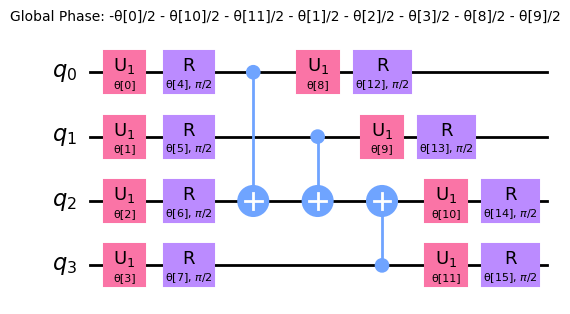

In [10]:
## logical circuit
ansatz.decompose().draw("mpl", style="clifford")


Depth  : 11
CZ   : 3
All ops: OrderedDict([('ry', 10), ('rz', 8), ('cz', 3), ('rx', 2)])


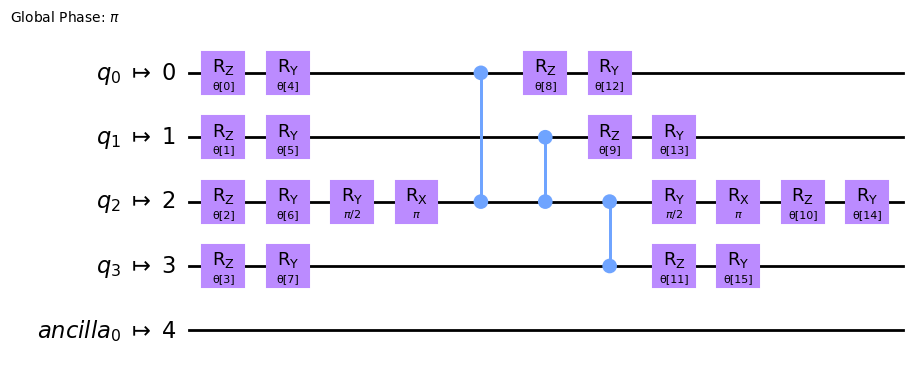

In [11]:
## plot transpiled circuit of cross_5q topology 
from qiskit import transpile
from qiskit.transpiler import CouplingMap


# Cross 5-qubit coupling map (center = qubit 2) 
cross_5q = CouplingMap([
    [0,2],[2,0],
    [1,2],[2,1],
    [3,2],[2,3],
    [4,2],[2,4],
])

ansatz_transpiled = transpile(
    ansatz,
    coupling_map=cross_5q,
    basis_gates=["rz", "rx", "ry", "cz"],         # can change based on native gate of sc qubits
    optimization_level=3,                         # can set to 0, 1, 2, 3
    seed_transpiler=42,
)

print(f"Depth  : {ansatz_transpiled.depth()}")
print(f"CZ   : {ansatz_transpiled.count_ops().get('cz', 0)}")
print(f"All ops: {ansatz_transpiled.count_ops()}")

ansatz_transpiled.draw("mpl", style="clifford")



# Noise from real backend(FakeFez)

### Choose topological structure on FakeBackend (ibm_fez)

In [12]:
from qiskit_ibm_runtime.fake_provider import FakeFez
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
from qiskit_aer.primitives import EstimatorV2 as AerEstimator
from qiskit import transpile

fake_backend = FakeFez()

noise_model_fez = NoiseModel.from_backend(fake_backend)
coupling_map_fez = fake_backend.coupling_map
basis_gates_fez = noise_model_fez.basis_gates

# HEA: q2 is most connected (center), map to physical qubit 3 (T-shape center of FakeFez)
initial_layout = {
    ansatz.qregs[0][0]: 2,   # logical q0 -> physical arm
    ansatz.qregs[0][1]: 4,   # logical q1 -> physical arm
    ansatz.qregs[0][2]: 3,   # logical q2 (HEA center) -> physical center
    ansatz.qregs[0][3]: 16,  # logical q3 -> physical arm end
}

ansatz_fez = transpile(
    ansatz,
    backend=fake_backend,
    optimization_level=3,
    initial_layout=initial_layout,
    seed_transpiler=42,
)

ops = ansatz_fez.count_ops()
print(f"Depth  : {ansatz_fez.depth()}")
print(f"CZ    : {ops.get('cz', 0)}")          # FakeFez backend use CZ rather than ecr, should be zero
print(f"All ops: {ops}")
print(f"Layout : {ansatz_fez.layout.final_index_layout()}")

Depth  : 16
CZ    : 3
All ops: OrderedDict([('rz', 26), ('sx', 17), ('cz', 3)])
Layout : [2, 4, 3, 16]


In [13]:
## calculate fixed distance vqe of HEA with spsa using FakeFez backend
qubit_ham_fez = qubit_hamiltonian.apply_layout(ansatz_fez.layout)

noisy_estimator_fez = AerEstimator(
    options={
        "backend_options": {
            "noise_model": noise_model_fez,
            "coupling_map": list(coupling_map_fez.get_edges()),
            "basis_gates": basis_gates_fez,
        },
        "run_options": {"shots": 8192, "seed": 42},
    }
)

history_fez = {"iter": 0, "energies": []}

def cost_function_fez(params):
    pub = (ansatz_fez, [qubit_ham_fez], [params])
    result = noisy_estimator_fez.run(pubs=[pub]).result()
    energy = float(result[0].data.evs[0])
    history_fez["iter"] += 1
    history_fez["energies"].append(energy)
    if history_fez["iter"] % 5 == 0:
        print(f"  iter {history_fez['iter']:3d}: E = {energy:.6f} Ha")
    return energy

# random init to avoid theta=0 local minimum
x0 = rng.uniform(-np.pi, np.pi, ansatz_fez.num_parameters)


result_fez = spsa.minimize(cost_function_fez, x0=x0)

# correct total energy
total_fez = (
    result_fez.fun
    + problem.nuclear_repulsion_energy
    # + problem.hamiltonian.constants["frozen_core"]
)
print(f"\nFakeFez noisy VQE : {total_fez:.6f} Ha")

  iter   5: E = -8.348954 Ha
  iter  10: E = -7.674609 Ha
  iter  15: E = -8.174594 Ha
  iter  20: E = -8.361462 Ha
  iter  25: E = -8.284173 Ha
  iter  30: E = -8.093382 Ha
  iter  35: E = -8.460387 Ha
  iter  40: E = -7.704226 Ha
  iter  45: E = -8.064127 Ha
  iter  50: E = -8.438380 Ha
  iter  55: E = -7.863265 Ha
  iter  60: E = -8.386161 Ha
  iter  65: E = -8.599995 Ha
  iter  70: E = -7.893262 Ha
  iter  75: E = -8.237110 Ha
  iter  80: E = -8.450221 Ha
  iter  85: E = -8.226138 Ha
  iter  90: E = -8.562016 Ha
  iter  95: E = -8.480241 Ha
  iter 100: E = -8.436871 Ha
  iter 105: E = -8.570775 Ha
  iter 110: E = -8.694325 Ha
  iter 115: E = -8.654074 Ha
  iter 120: E = -8.621592 Ha
  iter 125: E = -8.702428 Ha
  iter 130: E = -8.658924 Ha
  iter 135: E = -8.698583 Ha
  iter 140: E = -8.751670 Ha
  iter 145: E = -8.654754 Ha
  iter 150: E = -8.711649 Ha
  iter 155: E = -8.750639 Ha
  iter 160: E = -8.673373 Ha
  iter 165: E = -8.742599 Ha
  iter 170: E = -8.706638 Ha
  iter 175: E 

In [14]:
print(f"\nFakeFez noisy VQE : {total_fez:.6f} Ha")
print(f"FCI total         : {fci_electronic + problem.nuclear_repulsion_energy:.6f} Ha")
print(f"Error             : {(result_fez.fun - fci_electronic)*1000:+.4f} mHa")


FakeFez noisy VQE : -7.800163 Ha
FCI total         : -7.863439 Ha
Error             : +63.2765 mHa


In [15]:
## check FakeFez actual noise parameters
from qiskit_ibm_runtime.fake_provider import FakeFez
from qiskit_aer.noise import NoiseModel

fake_backend = FakeFez()
noise_model_fez = NoiseModel.from_backend(fake_backend)

# check gate error rates
props = fake_backend.properties()

print("Single-qubit gate errors:")
for gate in ["sx", "x"]:
    for qubit in range(5):
        try:
            err = props.gate_error(gate, [qubit])
            print(f"  {gate} q{qubit}: {err:.2e}")
        except:
            pass

# print("Two-qubit gate errors:")
# for gate_name in noise_model_fez.basis_gates:
#     print(f"\nGate: {gate_name}")
#     for qubit_combo in noise_model_fez._local_quantum_errors.get(gate_name, {}):
#         err = noise_model_fez._local_quantum_errors[gate_name][qubit_combo]
#         print(f"  qubits {qubit_combo}: {err}")

print("\nT1, T2:")
for qubit in range(5):
    try:
        t1 = props.t1(qubit)
        t2 = props.t2(qubit)
        print(f"  q{qubit}: T1={t1*1e6:.1f}μs, T2={t2*1e6:.1f}μs")
    except:
        pass
print(noise_model_fez)

Single-qubit gate errors:
  sx q0: 7.64e-04
  sx q1: 1.78e-04
  sx q2: 1.98e-04
  sx q3: 2.39e-04
  sx q4: 2.12e-04
  x q0: 7.64e-04
  x q1: 1.78e-04
  x q2: 1.98e-04
  x q3: 2.39e-04
  x q4: 2.12e-04

T1, T2:
  q0: T1=48.8μs, T2=42.4μs
  q1: T1=255.7μs, T2=302.8μs
  q2: T1=274.4μs, T2=100.0μs
  q3: T1=219.7μs, T2=215.5μs
  q4: T1=190.9μs, T2=161.9μs
NoiseModel:
  Basis gates: ['cz', 'delay', 'for_loop', 'id', 'if_else', 'measure', 'reset', 'rz', 'switch_case', 'sx', 'x']
  Instructions with noise: ['id', 'x', 'sx', 'reset', 'measure', 'cz']
  Qubits with noise: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 

# Build coupling map and noise model for topology of real device 

In [16]:
from qiskit.transpiler import CouplingMap
from qiskit_aer.noise import NoiseModel
from qiskit_aer import AerSimulator
from qiskit import transpile
import qiskit_aer.noise as noise

# # Cross 5-qubit coupling map (center = qubit 4) 
# cross_5q = CouplingMap([
#     [0,2],[2,0],
#     [1,2],[2,1],
#     [3,2],[2,3],
#     [4,2],[2,4],
# ])

# Noise model -- fetch from real device 
p1 = 2.2e-4   # single-qubit gate error 
p2 = 2e-3   # two-qubit gate error  
t1, t2 = 150e-6, 100e-6  # seconds     # T2* --> whole T2  

err1 = noise.depolarizing_error(p1, 1)
err2 = noise.depolarizing_error(p2, 2)

noise_model = noise.NoiseModel()        # can change to user defined noisemodel
noise_model.add_all_qubit_quantum_error(err1, ["rz", "sx", "x"])
noise_model.add_all_qubit_quantum_error(err2, ["cz"])

# Build simulator
cross_sim = AerSimulator(
    noise_model=noise_model,
    coupling_map=cross_5q,
    basis_gates=["rz", "rx", "ry", "cz"],
)

# Transpile LiH ansatz to this backend
ansatz_cross = transpile(
    ansatz,
    coupling_map=cross_5q,
    basis_gates=["rz", "rx", "ry", "cz"],
    optimization_level=3,
    seed_transpiler=42,
)

print(f"Depth : {ansatz_cross.depth()}")
print(f"CZ   : {ansatz_cross.count_ops().get('cz', 0)}")
print(f"Layout: {ansatz_cross.layout.final_index_layout()}")

Depth : 11
CZ   : 3
Layout: [0, 1, 2, 3]


In [17]:
from qiskit.transpiler import CouplingMap
from qiskit_aer.noise import NoiseModel, thermal_relaxation_error
from qiskit_aer import AerSimulator
from qiskit import transpile
import qiskit_aer.noise as noise

# Noise model for cross 5q topology 
p1 = 2.2e-4   # single-qubit depolarizing error
p2 = 2e-3     # two-qubit depolarizing error
t1 = 15e-6   # T1 relaxation time (seconds)
t2 = 10e-6   # T2 dephasing time (seconds)

# gate times (seconds) - adjust based on actual hardware calibration
gate_time_1q = 50e-9    # 50 ns for rx, ry, rz
gate_time_2q = 200e-9   # 200 ns for cz

# depolarizing errors
err1_dep = noise.depolarizing_error(p1, 1)
err2_dep = noise.depolarizing_error(p2, 2)

# thermal relaxation errors
err1_thermal = thermal_relaxation_error(t1, t2, gate_time_1q)
err2_thermal = thermal_relaxation_error(t1, t2, gate_time_2q).expand(
    thermal_relaxation_error(t1, t2, gate_time_2q)
)

# combine depolarizing + thermal relaxation
err1_combined = err1_dep.compose(err1_thermal)
err2_combined = err2_dep.compose(err2_thermal)

noise_model = noise.NoiseModel()
noise_model.add_all_qubit_quantum_error(err1_combined, ["rx", "ry", "rz"])
noise_model.add_all_qubit_quantum_error(err2_combined, ["cz"])

# Build simulator
cross_sim = AerSimulator(
    noise_model=noise_model,
    coupling_map=cross_5q,
    basis_gates=["rz", "rx", "ry", "cz"],
)

# Transpile ansatz to cross 5q topology
ansatz_cross = transpile(
    ansatz,
    coupling_map=cross_5q,
    basis_gates=["rz", "rx", "ry", "cz"],
    optimization_level=3,
    seed_transpiler=42,
)

print(f"Depth : {ansatz_cross.depth()}")
print(f"CZ    : {ansatz_cross.count_ops().get('cz', 0)}")
print(f"Layout: {ansatz_cross.layout.final_index_layout()}")

Depth : 11
CZ    : 3
Layout: [0, 1, 2, 3]


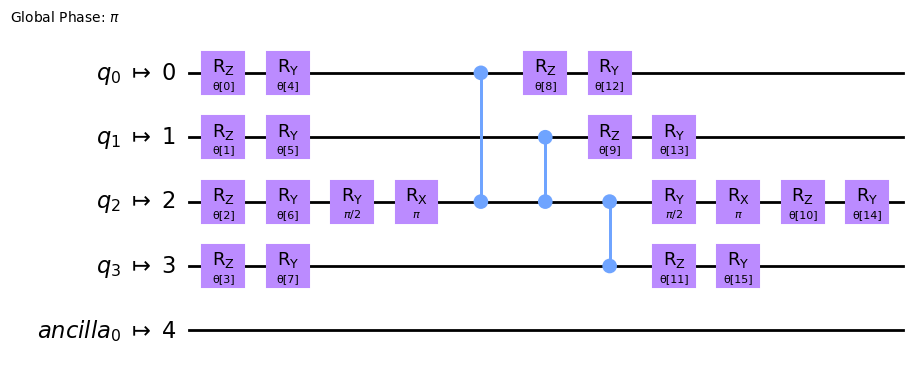

In [18]:
ansatz_cross.draw("mpl", style = "clifford")

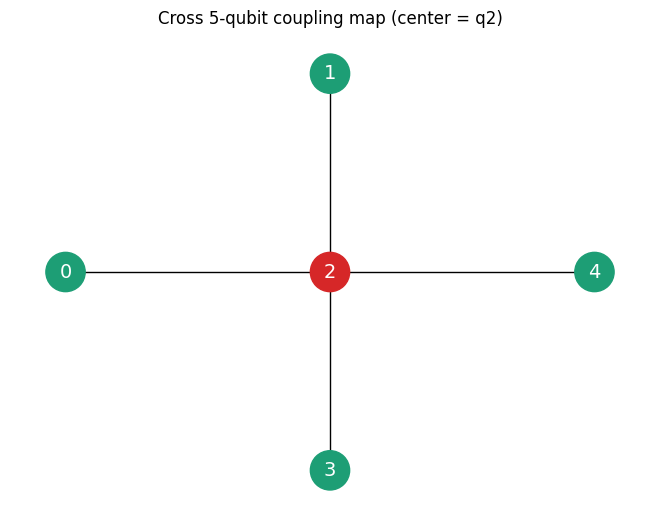

In [19]:
## coupling map visualization

import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()
G.add_edges_from(cross_5q.get_edges())

# center = q2
pos = {0: (-1, 0), 1: (0, 1), 2: (0, 0), 3: (0, -1), 4: (1, 0)}
colors = ["#1D9E75" if n != 2 else "#D62728" for n in G.nodes()]

nx.draw(G, pos=pos, with_labels=True, node_color=colors,
        node_size=800, font_color="white", font_size=14)
plt.title("Cross 5-qubit coupling map (center = q2)")
plt.show()

In [20]:
## calculate fixed distance vqe of HEA with spsa using defined cross_5q 
qubit_ham_cross = qubit_hamiltonian.apply_layout(ansatz_cross.layout)

noisy_estimator_cross = AerEstimator(
    options={
        "backend_options": {
            "noise_model": noise_model,
            "coupling_map": list(cross_5q.get_edges()),
            "basis_gates": ["rz", "ry", "rx", "cz"],
        },
        "run_options": {"shots": 8192, "seed": 42},
    }
)

history_cross = {"iter": 0, "energies": []}

def cost_function_cross(params):
    pub = (ansatz_cross, [qubit_ham_cross], [params])
    result = noisy_estimator_cross.run(pubs=[pub]).result()
    energy = float(result[0].data.evs[0])
    history_cross["iter"] += 1
    history_cross["energies"].append(energy)
    if history_cross["iter"] % 5 == 0:
        print(f"  iter {history_cross['iter']:3d}: E = {energy:.6f} Ha")
    return energy


x0 = rng.uniform(-np.pi, np.pi, ansatz_cross.num_parameters)


result_cross = spsa.minimize(cost_function_cross, x0=x0)

total_cross = (
    result_cross.fun
    + problem.nuclear_repulsion_energy
)
print(f"\nCross topology noisy VQE : {total_cross:.6f} Ha")
print(f"FCI total                : {fci_electronic + problem.nuclear_repulsion_energy:.6f} Ha")
print(f"Error                    : {(result_cross.fun - fci_electronic)*1000:+.4f} mHa")

  iter   5: E = -6.061855 Ha
  iter  10: E = -5.981694 Ha
  iter  15: E = -5.892307 Ha
  iter  20: E = -6.462233 Ha
  iter  25: E = -5.576398 Ha
  iter  30: E = -6.560902 Ha
  iter  35: E = -5.742712 Ha
  iter  40: E = -5.576176 Ha
  iter  45: E = -6.353363 Ha
  iter  50: E = -5.990645 Ha
  iter  55: E = -6.738881 Ha
  iter  60: E = -7.496251 Ha
  iter  65: E = -7.692054 Ha
  iter  70: E = -7.541947 Ha
  iter  75: E = -8.541939 Ha
  iter  80: E = -8.546584 Ha
  iter  85: E = -8.517336 Ha
  iter  90: E = -8.485548 Ha
  iter  95: E = -8.503789 Ha
  iter 100: E = -8.557360 Ha
  iter 105: E = -8.611787 Ha
  iter 110: E = -8.613229 Ha
  iter 115: E = -8.588243 Ha
  iter 120: E = -8.631037 Ha
  iter 125: E = -8.589709 Ha
  iter 130: E = -8.608057 Ha
  iter 135: E = -8.615649 Ha
  iter 140: E = -8.600246 Ha
  iter 145: E = -8.617278 Ha
  iter 150: E = -8.638888 Ha
  iter 155: E = -8.624954 Ha
  iter 160: E = -8.616118 Ha
  iter 165: E = -8.626503 Ha
  iter 170: E = -8.600681 Ha
  iter 175: E 

In [21]:
def run_vqe_noisy_at_distance(R, backend_type="fakefez"):
    """
    backend_type: "fakefez" or "cross"
    """
    drv = PySCFDriver(
        atom=f"Li 0.0 0.0 0.0; H 0.0 0.0 {R}",
        basis="sto3g", charge=0, spin=0, unit=DistanceUnit.ANGSTROM,
    )

    prob_ref = drv.run()
    frozen_shift = ActiveSpaceTransformer(2, 3).transform(prob_ref).hamiltonian.constants["ActiveSpaceTransformer"]

    prob = drv.run()
    prob = ActiveSpaceTransformer(num_electrons=4, num_spatial_orbitals=3).transform(prob)
    prob.hamiltonian.constants["frozen_core"] = frozen_shift

    mp = ParityMapper(num_particles=prob.num_particles)
    H = mp.map(prob.hamiltonian.second_q_op())

    shift = prob.nuclear_repulsion_energy
    fci_elec = float(np.linalg.eigvalsh(H.to_matrix())[0])

    ans = efficient_su2(
        num_qubits=4, reps=1,
        entanglement=[[0,2],[1,2],[3,2]],
        su2_gates=["rz", "ry"],
    )

    if backend_type == "fakefez":
        ans_t = transpile(
            ans,
            backend=fake_backend,
            optimization_level=3,
            initial_layout={
                ans.qregs[0][0]: 2,
                ans.qregs[0][1]: 4,
                ans.qregs[0][2]: 3,
                ans.qregs[0][3]: 16,
            },
            seed_transpiler=42,
        )
        H_t = H.apply_layout(ans_t.layout)
        est = AerEstimator(options={
            "backend_options": {
                "noise_model": noise_model_fez,
                "coupling_map": list(coupling_map_fez.get_edges()),
                "basis_gates": basis_gates_fez,
            },
            "run_options": {"shots": 8192, "seed": 42},         # increase for better SNR
        })

    else:  # cross
        ans_t = transpile(
            ans,
            coupling_map=cross_5q,
            basis_gates=["rz", "rx", "ry", "cz"],
            optimization_level=3,
            seed_transpiler=42,
        )
        H_t = H.apply_layout(ans_t.layout)
        est = AerEstimator(options={
            "backend_options": {
                "noise_model": noise_model,
                "coupling_map": list(cross_5q.get_edges()),
                "basis_gates": ["rz", "rx", "ry", "cz"],
            },
            "run_options": {"shots": 8192, "seed": 42},         # increase for better SNR
        })

    def cost(p):
        pub = (ans_t, [H_t], [p])
        return float(est.run(pubs=[pub]).result()[0].data.evs[0])

    clean_est = StatevectorEstimator()
    initial_elec = float(clean_est.run([(ans, H, [np.zeros(ans.num_parameters)])]).result()[0].data.evs[0])

    
    x0 = rng.uniform(-np.pi, np.pi, ans_t.num_parameters)
   
    res = spsa.minimize(cost, x0=x0)
    vqe_elec = float(res.fun)

    return initial_elec + shift, vqe_elec + shift, fci_elec + shift

R=0.50  FakeFez=-6.9399  Cross=-6.6492  FCI=-7.0291
R=0.60  FakeFez=-7.0559  Cross=-7.0250  FCI=-7.2998
R=0.70  FakeFez=-7.3484  Cross=-7.2177  FCI=-7.4862
R=0.80  FakeFez=-7.5363  Cross=-7.2905  FCI=-7.6160
R=0.90  FakeFez=-7.5371  Cross=-7.4993  FCI=-7.7059
R=1.00  FakeFez=-7.5800  Cross=-7.5714  FCI=-7.7676
R=1.10  FakeFez=-7.7025  Cross=-7.5965  FCI=-7.8090
R=1.20  FakeFez=-7.7116  Cross=-7.5502  FCI=-7.8358
R=1.30  FakeFez=-7.7956  Cross=-7.4621  FCI=-7.8522
R=1.40  FakeFez=-7.8249  Cross=-7.4959  FCI=-7.8608
R=1.45  FakeFez=-7.7190  Cross=-7.5433  FCI=-7.8629
R=1.50  FakeFez=-7.6894  Cross=-7.4902  FCI=-7.8637
R=1.55  FakeFez=-7.7802  Cross=-7.5232  FCI=-7.8634
R=1.60  FakeFez=-7.6799  Cross=-7.7452  FCI=-7.8622
R=1.65  FakeFez=-7.7874  Cross=-7.6003  FCI=-7.8602
R=1.70  FakeFez=-7.7900  Cross=-7.6383  FCI=-7.8576
R=1.75  FakeFez=-7.6846  Cross=-7.6610  FCI=-7.8543
R=1.80  FakeFez=-7.7942  Cross=-7.5102  FCI=-7.8505
R=2.00  FakeFez=-7.7161  Cross=-7.5646  FCI=-7.8316
R=2.20  Fake

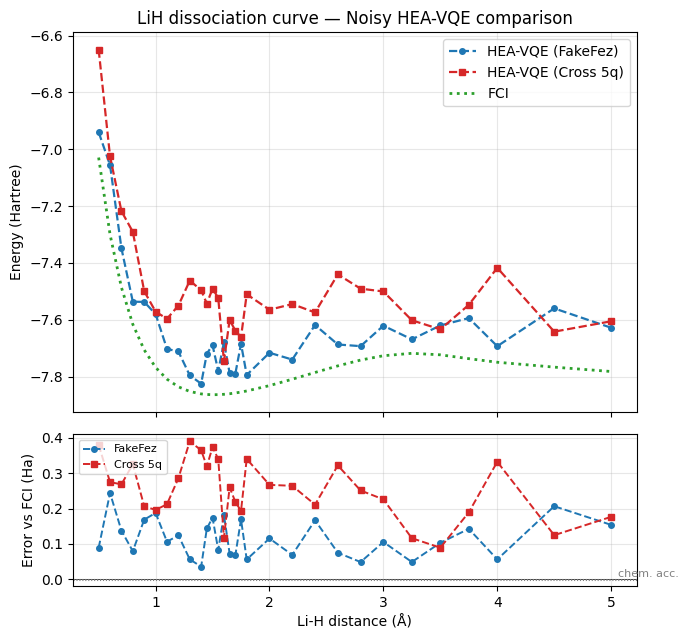

In [22]:
# Noisy VQE PEC scan: FakeFez vs Cross 5q and FCI
E_initial_n, E_vqe_fez, E_vqe_cross, E_fci_n = [], [], [], []

for R in distances:
    initial_f, vqe_f, fci_f = run_vqe_noisy_at_distance(float(R), backend_type="fakefez")
    _,          vqe_c, _     = run_vqe_noisy_at_distance(float(R), backend_type="cross")
    E_initial_n.append(initial_f)
    E_vqe_fez.append(vqe_f)
    E_vqe_cross.append(vqe_c)
    E_fci_n.append(fci_f)
    print(f"R={R:.2f}  FakeFez={vqe_f:.4f}  Cross={vqe_c:.4f}  FCI={fci_f:.4f}")

E_initial_n, E_vqe_fez, E_vqe_cross, E_fci_n = map(np.array, (E_initial_n, E_vqe_fez, E_vqe_cross, E_fci_n))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 6.5), sharex=True,
                               gridspec_kw={"height_ratios": [3, 1.2]})

# ax1.plot(distances, E_initial_n,  "-",   color="#888888", lw=1.4, label="Initial (θ=0)")
ax1.plot(distances, E_vqe_fez,    "o--", color="#1f77b4", lw=1.6, ms=4, label="HEA-VQE (FakeFez)")
ax1.plot(distances, E_vqe_cross,  "s--", color="#d62728", lw=1.6, ms=4, label="HEA-VQE (Cross 5q)")
ax1.plot(distances, E_fci_n,      ":",   color="#2ca02c", lw=2.0, label="FCI")
ax1.set_ylabel("Energy (Hartree)")
ax1.legend(loc="upper right")
ax1.grid(alpha=0.3)
ax1.set_title("LiH dissociation curve — Noisy HEA-VQE comparison")

# ax2.plot(distances, E_initial_n  - E_fci_n, "-",   color="#888888", lw=1.4, label="Initial (θ=0)")
ax2.plot(distances, E_vqe_fez    - E_fci_n, "o--", color="#1f77b4", lw=1.4, ms=4, label="FakeFez")
ax2.plot(distances, E_vqe_cross  - E_fci_n, "s--", color="#d62728", lw=1.4, ms=4, label="Cross 5q")
ax2.axhline(0, color="k", lw=0.5)
ax2.axhline( 1.6e-3, color="gray", ls=":", lw=0.8)
ax2.axhline(-1.6e-3, color="gray", ls=":", lw=0.8)
ax2.text(distances[-1], 1.6e-3, "  chem. acc.", fontsize=8, color="gray", va="bottom")
ax2.set_xlabel("Li-H distance (Å)")
ax2.set_ylabel("Error vs FCI (Ha)")
ax2.legend(loc="upper left", fontsize=8)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()